In [3]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA

df = pd.read_csv("wine-clustering.csv")

print(df.head())
print("Missing values:", df.isnull().sum().sum())

   Alcohol  Malic_Acid   Ash  Ash_Alcanity  Magnesium  Total_Phenols  \
0    14.23        1.71  2.43          15.6        127           2.80   
1    13.20        1.78  2.14          11.2        100           2.65   
2    13.16        2.36  2.67          18.6        101           2.80   
3    14.37        1.95  2.50          16.8        113           3.85   
4    13.24        2.59  2.87          21.0        118           2.80   

   Flavanoids  Nonflavanoid_Phenols  Proanthocyanins  Color_Intensity   Hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   OD280  Proline  
0   3.92     1065  
1   3.40     1050  
2   3.17     1185  
3   3.45    

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

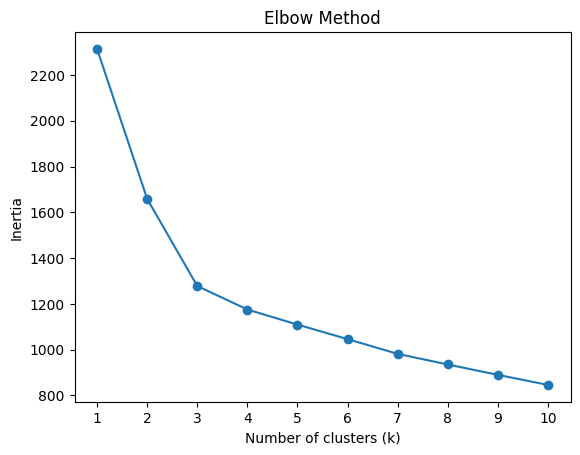

In [5]:
inertia = []

for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.plot(range(1, 11), inertia, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.xticks(range(1, 11))
plt.show()

In [6]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

dbscan = DBSCAN(eps=2.4, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

print("K-Means cluster sizes:")
print(pd.Series(kmeans_labels).value_counts().sort_index())

print("\nDBSCAN cluster sizes:")
print(pd.Series(dbscan_labels).value_counts().sort_index())

K-Means cluster sizes:
0    65
1    51
2    62
Name: count, dtype: int64

DBSCAN cluster sizes:
-1    36
 0    99
 1    43
Name: count, dtype: int64


In [7]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Variance retained:", pca.explained_variance_ratio_.sum())

Variance retained: 0.5540633835693527


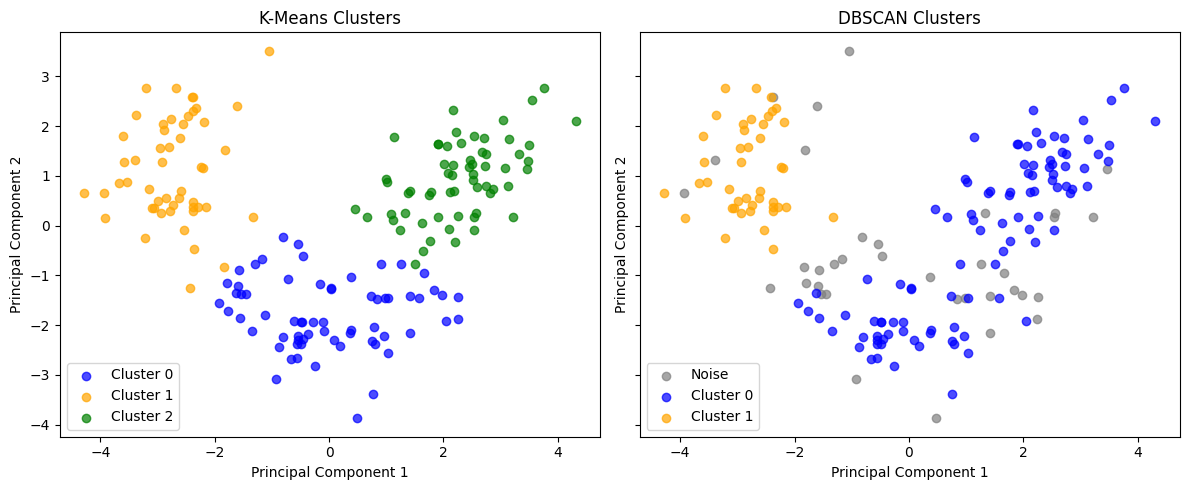

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

for ax, labels, title in zip(
    axes,
    [kmeans_labels, dbscan_labels],
    ["K-Means Clusters", "DBSCAN Clusters"]
):
    for cluster in sorted(set(labels)):
        mask = labels == cluster

        color = "gray" if cluster == -1 else ["blue", "orange", "green"][cluster]
        name = "Noise" if cluster == -1 else f"Cluster {cluster}"

        ax.scatter(
            X_pca[mask, 0],
            X_pca[mask, 1],
            color=color,
            label=name,
            alpha=0.7
        )

    ax.set_title(title)
    ax.set_xlabel("Principal Component 1")
    ax.set_ylabel("Principal Component 2")
    ax.legend()

plt.tight_layout()
plt.show()

In [9]:
results = df.copy()
results["KMeans"] = kmeans_labels
results["DBSCAN"] = dbscan_labels

features = [
    "Alcohol", "Malic_Acid", "Total_Phenols",
    "Flavanoids", "Color_Intensity", "Proline"
]

print("K-Means averages:")
print(results.groupby("KMeans")[features].mean().round(2))

print("\nDBSCAN averages:")
print(results.groupby("DBSCAN")[features].mean().round(2))

print("\nClustering comparison:")
print(pd.crosstab(results["KMeans"], results["DBSCAN"]))

K-Means averages:
        Alcohol  Malic_Acid  Total_Phenols  Flavanoids  Color_Intensity  \
KMeans                                                                    
0         12.25        1.90           2.25        2.05             2.97   
1         13.13        3.31           1.68        0.82             7.23   
2         13.68        2.00           2.85        3.00             5.45   

        Proline  
KMeans           
0        510.17  
1        619.06  
2       1100.23  

DBSCAN averages:
        Alcohol  Malic_Acid  Total_Phenols  Flavanoids  Color_Intensity  \
DBSCAN                                                                    
-1        12.54        2.37           2.40        2.04             4.32   
 0        13.10        1.87           2.56        2.57             4.42   
 1        13.14        3.38           1.60        0.77             7.14   

        Proline  
DBSCAN           
-1       617.94  
 0       845.26  
 1       628.37  

Clustering comparison:
DBSCAN  